# Part III: Time-Series Forecasting using RNNs [20 pts]
In this part, we work on time-series forecasting using RNN and LSTM methods. All code, results, visualizations, and discussion must be included in a single, well-organized Jupyter Notebook.
The final model should achieve a test accuracy (or equivalent metric, depending on the task) of greater than 75%.

## Step 1: Data exploration and preprocessing

1. Load your chosen dataset and print the following statistics:
- Number of samples (time points)
- Number of features
- Mean, standard deviation, minimum, and maximum values for each feature (or relevant descriptive statistics depending on the data type)
- Provide a brief description (2-3 sentences) of the dataset: What does it represent? Where does it come from (provide a link)? What are the key variables?

In [4]:
import pandas as pd

url = "Downloads/AirQualityUCI.csv"
df = pd.read_csv(url, sep=';')
print(df.head(5))
df = df.replace(',', '.', regex=True)

numerical = ['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH']
for x in numerical:
    df[x] = pd.to_numeric(df[x])
df=df.drop(columns=['Unnamed: 15','Unnamed: 16'])


print("\nNumber of samples:", len(df))
print("Number of features:", df.shape[1])
print("\nDescriptive statistics:")
print(df.describe())

         Date      Time CO(GT)  PT08.S1(CO)  NMHC(GT) C6H6(GT)  PT08.S2(NMHC)  \
0  10/03/2004  18.00.00    2,6       1360.0     150.0     11,9         1046.0   
1  10/03/2004  19.00.00      2       1292.0     112.0      9,4          955.0   
2  10/03/2004  20.00.00    2,2       1402.0      88.0      9,0          939.0   
3  10/03/2004  21.00.00    2,2       1376.0      80.0      9,2          948.0   
4  10/03/2004  22.00.00    1,6       1272.0      51.0      6,5          836.0   

   NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH  \
0    166.0        1056.0    113.0        1692.0       1268.0  13,6  48,9   
1    103.0        1174.0     92.0        1559.0        972.0  13,3  47,7   
2    131.0        1140.0    114.0        1555.0       1074.0  11,9  54,0   
3    172.0        1092.0    122.0        1584.0       1203.0  11,0  60,0   
4    131.0        1205.0    116.0        1490.0       1110.0  11,2  59,6   

       AH  Unnamed: 15  Unnamed: 16  
0  0,7578         

The dataset contains 9358 instances of hourly averaged responses from an array of 5 metal oxide chemical sensors embedded in an Air Quality Chemical Multisensor Device. It comes from https://archive.ics.uci.edu/dataset/360/air+quality . The key variables in this are CO and C6H6 concentraion for targets and other variables influence these values. We will have to draw a correlation map to identify which ones to consider and which ones to not.

2. Identify any missing values.

In [7]:
df.isnull().sum()

Date             114
Time             114
CO(GT)           114
PT08.S1(CO)      114
NMHC(GT)         114
C6H6(GT)         114
PT08.S2(NMHC)    114
NOx(GT)          114
PT08.S3(NOx)     114
NO2(GT)          114
PT08.S4(NO2)     114
PT08.S5(O3)      114
T                114
RH               114
AH               114
dtype: int64

3. Handle any missing values (imputation or removal).

In [9]:
import numpy as np

df.replace(-200, np.nan, inplace=True)

print(df.describe())

            CO(GT)  PT08.S1(CO)     NMHC(GT)     C6H6(GT)  PT08.S2(NMHC)  \
count  7674.000000  8991.000000   914.000000  8991.000000    8991.000000   
mean      2.152750  1099.833166   218.811816    10.083105     939.153376   
std       1.453252   217.080037   204.459921     7.449820     266.831429   
min       0.100000   647.000000     7.000000     0.100000     383.000000   
25%       1.100000   937.000000    67.000000     4.400000     734.500000   
50%       1.800000  1063.000000   150.000000     8.200000     909.000000   
75%       2.900000  1231.000000   297.000000    14.000000    1116.000000   
max      11.900000  2040.000000  1189.000000    63.700000    2214.000000   

           NOx(GT)  PT08.S3(NOx)      NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
count  7718.000000   8991.000000  7715.000000   8991.000000  8991.000000   
mean    246.896735    835.493605   113.091251   1456.264598  1022.906128   
std     212.979168    256.817320    48.370108    346.206794   398.484288   
min       2

In [10]:

df = df.ffill()
print(df.describe())

            CO(GT)  PT08.S1(CO)     NMHC(GT)     C6H6(GT)  PT08.S2(NMHC)  \
count  9471.000000  9471.000000  9471.000000  9471.000000    9471.000000   
mean      2.083613  1102.348432   270.550945    10.210970     943.805512   
std       1.460984   218.289826    72.865938     7.522406     268.195857   
min       0.100000   647.000000     7.000000     0.100000     383.000000   
25%       1.000000   940.000000   275.000000     4.400000     734.000000   
50%       1.700000  1065.000000   275.000000     8.400000     915.000000   
75%       2.700000  1235.000000   275.000000    13.900000    1113.500000   
max      11.900000  2040.000000  1189.000000    63.700000    2214.000000   

           NOx(GT)  PT08.S3(NOx)      NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
count  9471.000000   9471.000000  9471.000000   9471.000000  9471.000000   
mean    241.023334    830.590751   110.120051   1449.114455  1027.929891   
std     205.388102    254.912036    47.369418    347.139644   409.105364   
min       2

4. Create at least three different visualizations to explore the dataset.

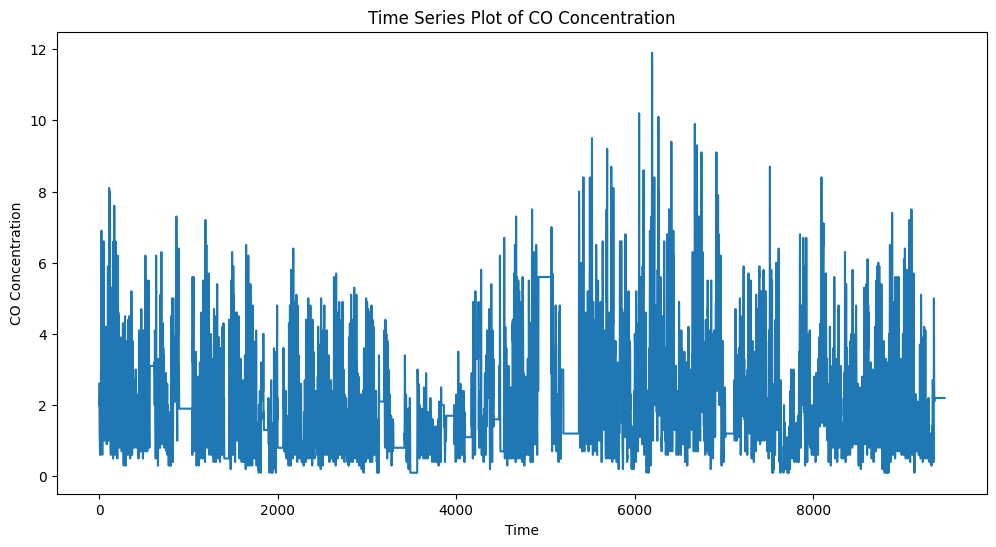

In [12]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))
plt.plot(df['CO(GT)'])
plt.title('Time Series Plot of CO Concentration')
plt.xlabel('Time')
plt.ylabel('CO Concentration')
plt.show()


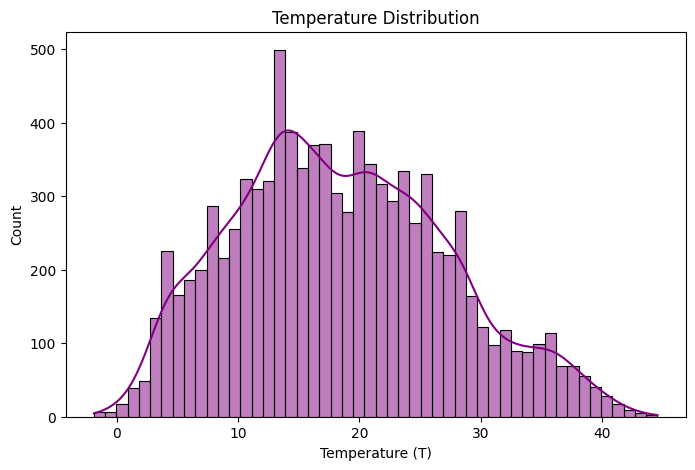

In [13]:

import seaborn as sns
plt.figure(figsize=(8, 5))
sns.histplot(df['T'], bins=50, kde=True, color='purple')
plt.title("Temperature Distribution")
plt.xlabel("Temperature (T)")
plt.show()

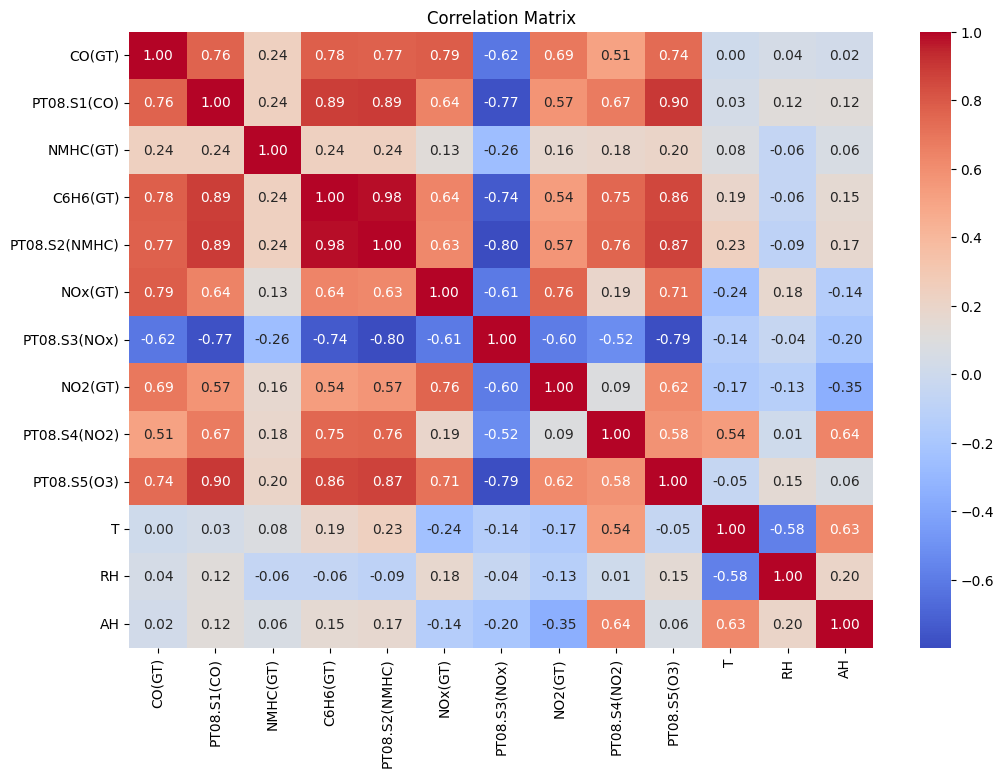

In [14]:
cdf=df.drop(columns=['Date','Time'])
cmatrix = cdf.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cmatrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

It is at this point that we should also figure out what our target variable is. For Air Quality, we can look at the CO concentraion . If there is a high CO concentration then it means the air quality is poor due to large of amount of CO emission. From the correlation graph we should be able to pick what variables are important in using for the model.

5. Normalize or standardize your data using appropriate techniques.

In [17]:
from sklearn.preprocessing import MinMaxScaler
df=df.drop(columns=['Date','Time'])
scaler = MinMaxScaler()
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

train_data = df.iloc[:train_size]
val_data = df.iloc[train_size:train_size + val_size]
test_data = df.iloc[train_size + val_size:]

scaler.fit(train_data[numerical])
train_data[numerical] = scaler.transform(train_data[numerical])
val_data[numerical] = scaler.transform(val_data[numerical])
test_data[numerical] = scaler.transform(test_data[numerical])

C:\Users\kisor\AppData\Local\Temp\ipykernel_15940\162636865.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[numerical] = scaler.transform(train_data[numerical])
C:\Users\kisor\AppData\Local\Temp\ipykernel_15940\162636865.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_data[numerical] = scaler.transform(val_data[numerical])
C:\Users\kisor\AppData\Local\Temp\ipykernel_15940\162636865.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [18]:
df

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,2.2,1071.0,275.0,11.9,1047.0,265.0,654.0,168.0,1129.0,816.0,28.5,13.1,0.5028
9467,2.2,1071.0,275.0,11.9,1047.0,265.0,654.0,168.0,1129.0,816.0,28.5,13.1,0.5028
9468,2.2,1071.0,275.0,11.9,1047.0,265.0,654.0,168.0,1129.0,816.0,28.5,13.1,0.5028
9469,2.2,1071.0,275.0,11.9,1047.0,265.0,654.0,168.0,1129.0,816.0,28.5,13.1,0.5028


6. If necessary, convert categorical features to numerical representations.
7. Split the data into training, validation, and testing sets.
8. Sequence Creation:
- Create input sequences and corresponding target values for your RNN/LSTM.
- Choose a sequence length.
- Create a function to generate sequences.

In [20]:

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data.iloc[i:(i + seq_length)].values
        y = data.iloc[i + seq_length].values  
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)


seq_length = 20  


X_train, y_train = create_sequences(train_data[numerical], seq_length)
X_val, y_val = create_sequences(val_data[numerical], seq_length)
X_test, y_test = create_sequences(test_data[numerical], seq_length)


X_train, y_train = np.array(X_train), np.array(y_train)
X_val, y_val = np.array(X_val), np.array(y_val)
X_test, y_test = np.array(X_test), np.array(y_test)

print("cell done")


cell done


## Step 2: Model development

1. Choose either an RNN or LSTM network for your time-series forecasting task.

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary

class StackedRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout_rate, output_size):
        super(StackedRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :]) 
        return out

print("cell done")


cell done


In [24]:
class BidirectionalRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout_rate, output_size):
        super(BidirectionalRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate, bidirectional=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size * 2, output_size) 
    
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])  
        return out

print("cell done")

cell done


2. Train your model using an appropriate loss function and optimizer.

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.tensorboard import SummaryWriter

input_size = X_train.shape[2]  
hidden_size = 64  
num_layers = 3  
dropout_rate = 0.3  
target_size = X_train.shape[2] 
learning_rate = 0.001
batch_size = 64
epochs = 50
early_stopping_patience = 5

writer = SummaryWriter()

def create_dataloader(X, y, batch_size):
    dataset = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32))
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

train_loader = create_dataloader(X_train, y_train, batch_size)
val_loader = create_dataloader(X_val, y_val, batch_size)
test_loader = create_dataloader(X_test, y_test, batch_size)

model = StackedRNN(input_size, hidden_size, num_layers, dropout_rate, target_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

summary(model, input_size=(batch_size, seq_length, input_size))

best_val_loss = float('inf')
stopping_counter = 0
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    writer.add_scalar("Loss/Train", train_loss, epoch)
    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    writer.add_scalar("Loss/Validation", val_loss, epoch)
    
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        stopping_counter = 0  
    else:
        stopping_counter += 1
        if stopping_counter >= early_stopping_patience:
            break


Epoch 1/50 - Train Loss: 0.0226, Val Loss: 0.0058
Epoch 2/50 - Train Loss: 0.0066, Val Loss: 0.0040
Epoch 3/50 - Train Loss: 0.0053, Val Loss: 0.0036
Epoch 4/50 - Train Loss: 0.0046, Val Loss: 0.0032
Epoch 5/50 - Train Loss: 0.0041, Val Loss: 0.0030
Epoch 6/50 - Train Loss: 0.0039, Val Loss: 0.0029
Epoch 7/50 - Train Loss: 0.0036, Val Loss: 0.0026
Epoch 8/50 - Train Loss: 0.0036, Val Loss: 0.0027
Epoch 9/50 - Train Loss: 0.0035, Val Loss: 0.0024
Epoch 10/50 - Train Loss: 0.0034, Val Loss: 0.0023
Epoch 11/50 - Train Loss: 0.0033, Val Loss: 0.0024
Epoch 12/50 - Train Loss: 0.0032, Val Loss: 0.0023
Epoch 13/50 - Train Loss: 0.0032, Val Loss: 0.0025
Epoch 14/50 - Train Loss: 0.0031, Val Loss: 0.0023
Epoch 15/50 - Train Loss: 0.0031, Val Loss: 0.0022
Epoch 16/50 - Train Loss: 0.0031, Val Loss: 0.0022
Epoch 17/50 - Train Loss: 0.0029, Val Loss: 0.0023
Epoch 18/50 - Train Loss: 0.0031, Val Loss: 0.0028
Epoch 19/50 - Train Loss: 0.0030, Val Loss: 0.0023
Epoch 20/50 - Train Loss: 0.0030, Val Lo

In [27]:
model.eval()
test_loss = 0
y_true, y_pred = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        output = model(X_batch)
        loss = criterion(output, y_batch)
        test_loss += loss.item()
        y_true.append(y_batch.cpu().numpy())
        y_pred.append(output.cpu().numpy())

test_loss /= len(test_loader)
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"Test Loss: {test_loss:.4f}")
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2 Score: {r2:.4f}")


Test Loss: 0.0021
MAE: 0.0316, RMSE: 0.0462, R2 Score: 0.8583


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.tensorboard import SummaryWriter

input_size = X_train.shape[2]  
hidden_size = 64  
num_layers = 3  
dropout_rate = 0.3  
target_size = X_train.shape[2] 
learning_rate = 0.001
batch_size = 64
epochs = 50
early_stopping_patience = 5

writer = SummaryWriter()

def create_dataloader(X, y, batch_size):
    dataset = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32))
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

train_loader = create_dataloader(X_train, y_train, batch_size)
val_loader = create_dataloader(X_val, y_val, batch_size)
test_loader = create_dataloader(X_test, y_test, batch_size)

model = BidirectionalRNN(input_size, hidden_size, num_layers, dropout_rate, target_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

summary(model, input_size=(batch_size, seq_length, input_size))

best_val_loss = float('inf')
stopping_counter = 0
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    writer.add_scalar("Loss/Train", train_loss, epoch)
    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    writer.add_scalar("Loss/Validation", val_loss, epoch)
    
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        stopping_counter = 0
    else:
        stopping_counter += 1
        if stopping_counter >= early_stopping_patience:
            break


Epoch 1/50 - Train Loss: 0.0143, Val Loss: 0.0035
Epoch 2/50 - Train Loss: 0.0048, Val Loss: 0.0031
Epoch 3/50 - Train Loss: 0.0040, Val Loss: 0.0026
Epoch 4/50 - Train Loss: 0.0036, Val Loss: 0.0024
Epoch 5/50 - Train Loss: 0.0033, Val Loss: 0.0021
Epoch 6/50 - Train Loss: 0.0031, Val Loss: 0.0021
Epoch 7/50 - Train Loss: 0.0030, Val Loss: 0.0023
Epoch 8/50 - Train Loss: 0.0030, Val Loss: 0.0020
Epoch 9/50 - Train Loss: 0.0029, Val Loss: 0.0023
Epoch 10/50 - Train Loss: 0.0028, Val Loss: 0.0019
Epoch 11/50 - Train Loss: 0.0028, Val Loss: 0.0020
Epoch 12/50 - Train Loss: 0.0027, Val Loss: 0.0020
Epoch 13/50 - Train Loss: 0.0027, Val Loss: 0.0022
Epoch 14/50 - Train Loss: 0.0026, Val Loss: 0.0021
Epoch 15/50 - Train Loss: 0.0026, Val Loss: 0.0019
Epoch 16/50 - Train Loss: 0.0025, Val Loss: 0.0019
Epoch 17/50 - Train Loss: 0.0026, Val Loss: 0.0020
Epoch 18/50 - Train Loss: 0.0025, Val Loss: 0.0020
Epoch 19/50 - Train Loss: 0.0026, Val Loss: 0.0023
Epoch 20/50 - Train Loss: 0.0025, Val Lo

3. Save the weights of the trained neural network that provides the best results.

In [30]:
#torch.save(model.state_dict(), "a1_part_rsaravan_kisorese_wt.pt")

## Step 3: Evaluation and analysis

1. Evaluate your trained model on the test set.

In [33]:

model.eval()
test_loss = 0
y_true, y_pred = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        output = model(X_batch)
        loss = criterion(output, y_batch)
        test_loss += loss.item()
        y_true.append(y_batch.cpu().numpy())
        y_pred.append(output.cpu().numpy())

test_loss /= len(test_loader)
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)



2. Report relevant metrics.

In [35]:
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"Test Loss: {test_loss:.4f}")
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2 Score: {r2:.4f}")


Test Loss: 0.0019
MAE: 0.0280, RMSE: 0.0431, R2 Score: 0.8745


3. Provide various plots.

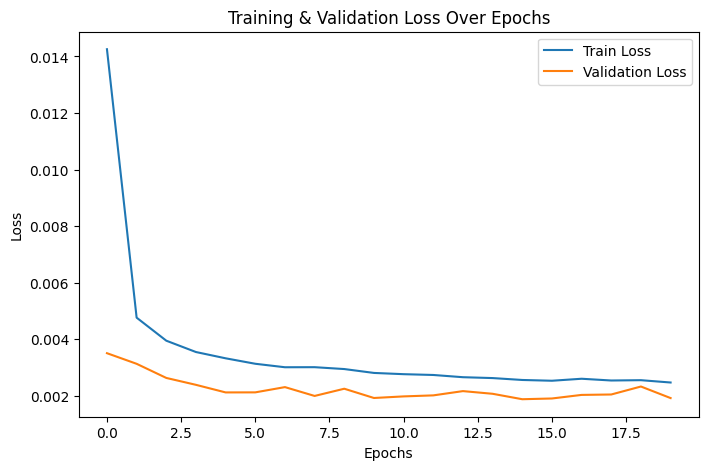

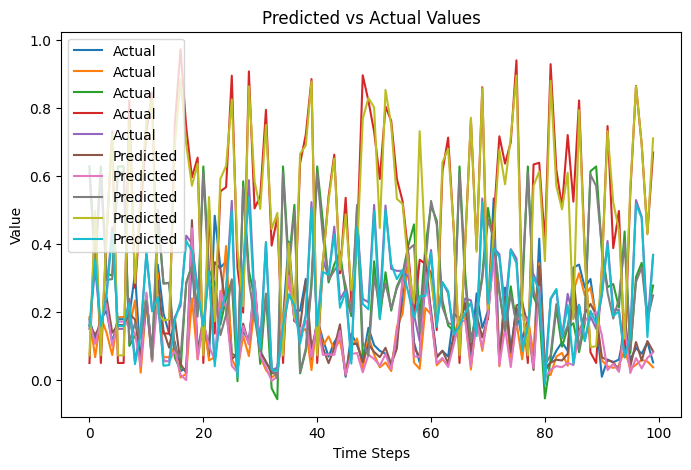

In [37]:

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss Over Epochs')
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(y_true[:100], label='Actual')
plt.plot(y_pred[:100], label='Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.title('Predicted vs Actual Values')
plt.show()

writer.close()


4. Discuss and analyze.

- The dataset was a time series dataset that contained records of air quality with the measurements of concentration of various gases present recorded hourly. We figured out a lot of NULL values were makred as -200 in the dataset (potential a default null value in the measurement device) and manually converted it to NaN to make use of forward fill working properly to fill gaps. 
- The final best model we used awas a bidirectional model with 3 Bi_RNN layers, 64 units per layer, tanh activation function, dropou of 0.3, and had a fully connected linear layer .
- Bidirectional RNN performed better than the StackedRNN when tested because Bi_RNN looks at past and previous records to provide accurate results. ALbeit the R^2 values weren't that far away from each other (namely 87% and 85%). When we went with sequence length of 10 it was fast but less accurate than 20. Sequence length of 50 ended up giving more accurate results but slower output so we decided on 20 being the sweet spot for sequence length. Going with 128 didnt improve performance by a huge margin (89% R2 value).
- The dataset didnt have much variations within chunks so we might have issues when there are extreme cases.
- Limitations would be that forward fill doesnt necessarily provide the best solution for filling gaps, it was only used as a stopgap testing method. A properly built mixed RNN would outperform a Bi_RNN model in the long term so this is necessarily not the best model
- Potentially could be improved by using LSTMs as opposed to simple RNN models. Data preprocessing could have been better as the relevant field knowledge was lacking besides just saying "Oh CO concentration means pollution". Expert consultation could have resulted in picking features more carefully or filling blanks better.

5. References.

- https://pytorch.org/tutorials/beginner/saving_loading_models.html
- https://pytorch.org/docs/stable/generated/torch.nn.RNN.html
- https://archive.ics.uci.edu/dataset/360/air+quality
- https://www.unep.org/news-and-stories/story/how-air-quality-measured
- Assignment was also using resources used from 